In [1]:
import os
import tensorflow as tf
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import permutations, combinations
from matplotlib import rcParams, cycler
sys.path.append(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1]))
from sgcc7 import *

In [4]:
## Random optimization run (truly random set of permutations)
perm_choices = np.array(list(permutations(permutations(np.arange(3)), 2)))
random_index = np.random.randint(0,29,size=(4000,7))
random_perm = perm_choices[random_index]
P0 = tf.one_hot(
    random_perm,
    3,
    axis=-1,
)
P0 = tf.transpose(P0, (0,1,2,4,3))
P0 = tf.where(P0 == 1.0, 
                  tf.ones_like(P0) * 10.0,   # large positive
                  tf.ones_like(P0) * -10.0)  # large negative


In [6]:
P0

<tf.Tensor: shape=(4000, 7, 2, 3, 3), dtype=float32, numpy=
array([[[[[-10., -10.,  10.],
          [ 10., -10., -10.],
          [-10.,  10., -10.]],

         [[ 10., -10., -10.],
          [-10.,  10., -10.],
          [-10., -10.,  10.]]],


        [[[-10.,  10., -10.],
          [-10., -10.,  10.],
          [ 10., -10., -10.]],

         [[ 10., -10., -10.],
          [-10.,  10., -10.],
          [-10., -10.,  10.]]],


        [[[-10., -10.,  10.],
          [ 10., -10., -10.],
          [-10.,  10., -10.]],

         [[-10.,  10., -10.],
          [-10., -10.,  10.],
          [ 10., -10., -10.]]],


        ...,


        [[[-10., -10.,  10.],
          [-10.,  10., -10.],
          [ 10., -10., -10.]],

         [[ 10., -10., -10.],
          [-10.,  10., -10.],
          [-10., -10.,  10.]]],


        [[[ 10., -10., -10.],
          [-10., -10.,  10.],
          [-10.,  10., -10.]],

         [[-10., -10.,  10.],
          [-10.,  10., -10.],
          [ 10., -10., -10.]]

In [ ]:
## Try running the optimizer with no identifiability
## See what the order permutations are for the top N exploration samples
## Reoptimize on just that discrete set of permutations
## See which one wins out

In [2]:
plt.rcParams['figure.dpi'] = 300
fontsize = 8
linewidth = 0.5

In [3]:
def vector_len(a: np.ndarray): 
    # calculate the length of a vector by calculating the square root of its self dot product
    
    return np.sqrt(np.dot(a, a))

def matrix_len(M, axis = 1, mean_center = False):
    if mean_center:
        return np.apply_along_axis(
            lambda v: vector_len(v-v.mean()), 
            axis = axis, arr = M
                            )
    else:
        return np.apply_along_axis(
            lambda v: vector_len(v), 
            axis = axis, arr = M
                            )
    
def pairwise_correlation(M, axis = 0):
    
    if axis == 0:
        Mcv = M - M.mean(1)[:, np.newaxis]
        Mcv = Mcv@Mcv.T
        
        denom = matrix_len(M, axis = 1, mean_center = True)
        denom = np.outer(denom, denom)
        return Mcv/denom
            
    if axis == 1:
        Mcv = M - M.mean()[np.newaxis,:]
        Mcv = Mcv.T@Mcv
        
        denom = matrix_len(M, axis = 0, mean_center = True)
        denom = np.outer(denom, denom)
        return Mcv/denom

In [4]:
param_bounds = {
    "fts": [0, 175],
    "t": [40, 125],
    "ampc": [0.01, 0.1],
    'ampm': [0,3],
    "ampg": [0.1, 4],
    "ampw": [0.01, 0.08],
    "d": [10, 40],
    "inh_d": [0, 40],
    "inh_w": [0, 3],
}

In [ ]:
perm_choices = np.array(list(permutations(permutations(np.arange(3)), 2)))
P = tf.one_hot(
    perm_choices,
    3,
    axis=-1,
)
P = tf.transpose(P, (0,1,2,4,3))
random_index = np.random.randint(0,29,size=(120,7))
random_perm = np.array([perm_choices[random_index] for i in range(100)]).reshape(12000,7,2,3)

In [284]:
perm_choices = np.array(list(permutations(permutations(np.arange(3)), 2)))
P = tf.one_hot(
    perm_choices,
    3,
    axis=-1,
)
P = tf.transpose(P, (0,1,3,2))

In [293]:

# P has shape (30, 2, 3, 3)
# You want weights of shape (n_samples, 7, 30) 
# so that after weighting and summing over the 30 permutations
# you get (n_samples, 7, 2, 3, 3)
n_samples = 100
# Learnable logits drawn from normal distribution
# shape: (n_samples, 7, 30)
logits = tf.Variable(
    tf.random.normal(shape=(n_samples, 7, 30), mean=0.0, stddev=1.0)
)

# Convert to probabilities via softmax over the 30 permutations
probs = model.sinkhorn(tf.nn.softmax(logits, axis=-1), temperature = 0.001)  # shape: (n_samples, 7, 30)
probs[0,0]

# # Reshape P for broadcasting
# # P: (30, 2, 3, 3) -> (1, 1, 30, 2, 3, 3)
# P_expanded = tf.reshape(P, (1, 1, 30, 2, 3, 3))

# # Reshape probs for broadcasting
# # probs: (n_samples, 7, 30) -> (n_samples, 7, 30, 1, 1, 1)
# probs_expanded = tf.reshape(probs, (n_samples, 7, 30, 1, 1, 1))

# # Weighted sum over the 30 permutations
# # Result shape: (n_samples, 7, 2, 3, 3)
# soft_P = tf.reduce_sum(probs_expanded * P_expanded, axis=2)

TypeError: sinkhorn() got an unexpected keyword argument 'temperature'

In [270]:
choice_matrix = np.random.normal(0,1,(1000,30))

In [278]:
Res = choice_matrix @ perm_choices.reshape(30,6)

In [280]:
Res.shape

(1000, 6)

In [276]:
perm_choices.reshape(30,6)

array([[0, 1, 2, 0, 2, 1],
       [0, 1, 2, 1, 0, 2],
       [0, 1, 2, 1, 2, 0],
       [0, 1, 2, 2, 0, 1],
       [0, 1, 2, 2, 1, 0],
       [0, 2, 1, 0, 1, 2],
       [0, 2, 1, 1, 0, 2],
       [0, 2, 1, 1, 2, 0],
       [0, 2, 1, 2, 0, 1],
       [0, 2, 1, 2, 1, 0],
       [1, 0, 2, 0, 1, 2],
       [1, 0, 2, 0, 2, 1],
       [1, 0, 2, 1, 2, 0],
       [1, 0, 2, 2, 0, 1],
       [1, 0, 2, 2, 1, 0],
       [1, 2, 0, 0, 1, 2],
       [1, 2, 0, 0, 2, 1],
       [1, 2, 0, 1, 0, 2],
       [1, 2, 0, 2, 0, 1],
       [1, 2, 0, 2, 1, 0],
       [2, 0, 1, 0, 1, 2],
       [2, 0, 1, 0, 2, 1],
       [2, 0, 1, 1, 0, 2],
       [2, 0, 1, 1, 2, 0],
       [2, 0, 1, 2, 1, 0],
       [2, 1, 0, 0, 1, 2],
       [2, 1, 0, 0, 2, 1],
       [2, 1, 0, 1, 0, 2],
       [2, 1, 0, 1, 2, 0],
       [2, 1, 0, 2, 0, 1]])

In [269]:
random_perm.shape

(12000, 7, 2, 3)

In [229]:
all_perm = []
for i in range(10000):
    all_perm.append(pd.DataFrame(random_perm[i,:,0].T).corr(method='spearman').values)
all_perm = np.array(all_perm)

In [175]:
all_perm.shape

(10000, 7, 7)

In [ ]:
np.unique(np.where(all_perm==all_perm.min(0))[0])

(10000,)

In [191]:
from scipy.stats import spearmanr

In [193]:
spearmanr(
    [3,2,1],
    [1,2,3]
)

SignificanceResult(statistic=-1.0, pvalue=0.0)

In [226]:
random_perm[19]

array([[[0, 2, 1],
        [2, 1, 0]],

       [[2, 0, 1],
        [1, 0, 2]],

       [[1, 2, 0],
        [0, 2, 1]],

       [[2, 0, 1],
        [2, 1, 0]],

       [[2, 0, 1],
        [0, 1, 2]],

       [[0, 1, 2],
        [2, 1, 0]],

       [[0, 2, 1],
        [1, 2, 0]]])

In [211]:
np.where(all_perm.mean((1,2)) == all_perm.mean((1,2)).min())[0]

array([   4,    7,   15, ..., 9989, 9990, 9995], dtype=int64)

<Axes: >

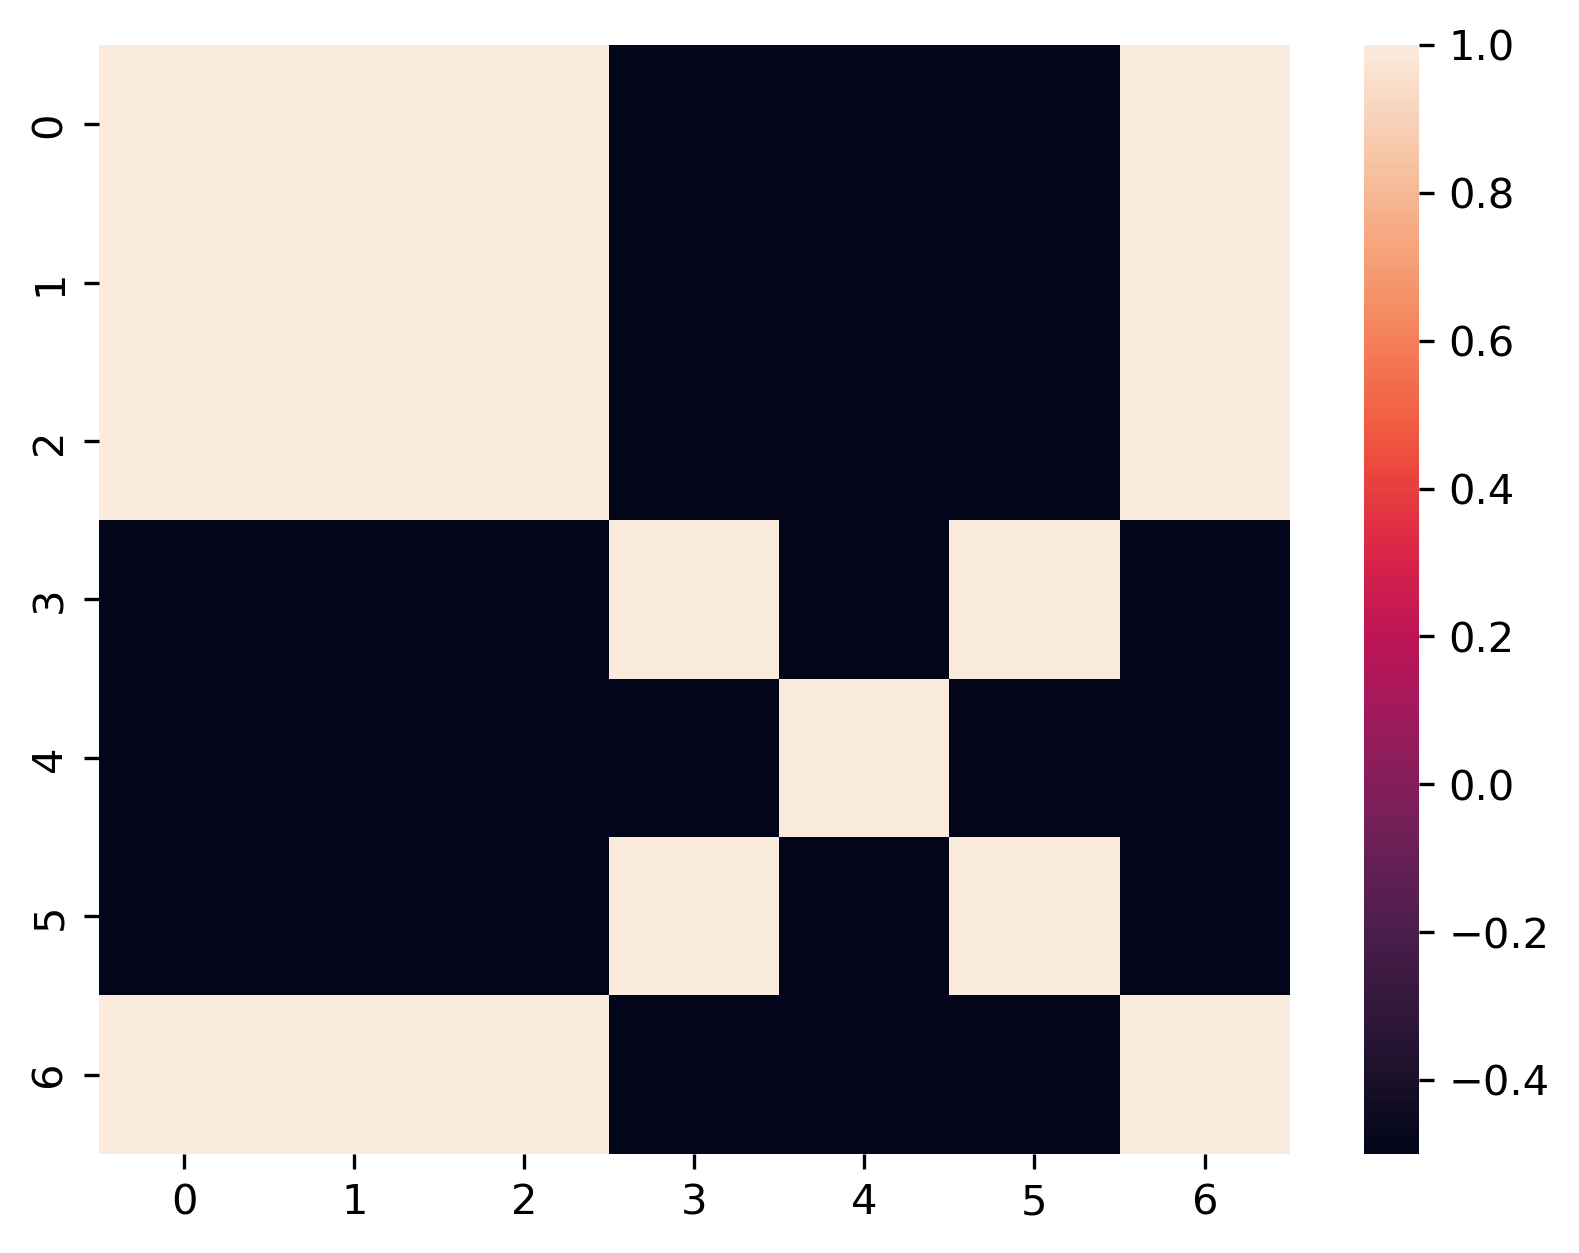

In [240]:
sns.heatmap(all_perm[100])

In [241]:
P = tf.one_hot(
    random_perm,
    3,
    axis=-1,
)
P = tf.transpose(P, (0,1,2,4,3))

P = tf.where(P == 1.0, 
                  tf.ones_like(P) * 10.0,   # large positive
                  tf.ones_like(P) * -10.0)  # large negative

In [242]:
P.shape

TensorShape([12000, 7, 2, 3, 3])

In [ ]:
## Fully optimize the best sample for each permutation
index_batch = tf.data.Dataset.from_tensor_slices(np.arange(P.shape[0]))  
index_batch = index_batch.batch(4000)
index_batch = index_batch.prefetch(tf.data.AUTOTUNE)  

optimized_permutation_params = {
    'dLGN_params':[],
    'V1_params':[]
}

permutation_loss_decay = []
for i in index_batch:
    perm = P.numpy()[i]
    model = SGCCircuit(bounds = param_bounds, identify=True, enforce_permutation=perm)
    model.initialize_random_parameters(2,3,4000)
    optimizer = Optimize(model, epochs=5000, loss_threshold=0)
    optimizer.fit(X, Y_true)

    permutation_loss_decay.append(optimizer.outputs['loss_decay'])
    optimized_permutation_params['dLGN_params'].append(optimizer.outputs['final_epoch_params']['dLGN_params'])
    optimized_permutation_params['V1_params'].append(optimizer.outputs['final_epoch_params']['V1_params'])

optimized_permutation_params = {
    'dLGN_params': np.concatenate(optimized_permutation_params['dLGN_params'], axis=0), 
    'V1_params': np.concatenate(optimized_permutation_params['V1_params'], axis=0)
}
result =  {
    'loss_decay': np.concatenate(permutation_loss_decay, axis = 1), 
    'params': optimized_permutation_params
}

with open('permutation_test_results.pkl', 'wb') as f:
    pickle.dump(result, f)

Optimizer initialized with <keras.optimizers.optimizer_v2.adam.Adam object at 0x0000027483E15100>
Training step = 0, N_exploration_samples = 4000,
min_loss = 0.6568715572357178
med_loss = 12.379390716552734
max_loss = 112.8099594116211

Training step = 100, N_exploration_samples = 4000,
min_loss = 0.42466968297958374
med_loss = 9.360433578491211
max_loss = 103.22465515136719

Training step = 200, N_exploration_samples = 4000,
min_loss = 0.2952330410480499
med_loss = 7.159485816955566
max_loss = 94.05477905273438

Training step = 300, N_exploration_samples = 4000,
min_loss = 0.23661881685256958
med_loss = 5.532001495361328
max_loss = 85.23251342773438

Training step = 400, N_exploration_samples = 4000,
min_loss = 0.21346771717071533
med_loss = 4.3076677322387695
max_loss = 76.73896026611328

Training step = 500, N_exploration_samples = 4000,
min_loss = 0.20389968156814575
med_loss = 3.399526596069336
max_loss = 68.59672546386719

Training step = 600, N_exploration_samples = 4000,
min_lo

In [244]:
with open('permutation_test_results.pkl', 'wb') as f:
    pickle.dump(result, f)

In [ ]:
# # Make the permutation matrices
# perm_combos = np.array(list(combinations((combinations(permutations(np.arange(3)), 2)), 7)))#.transpose(0,2,3,1)

# P = tf.one_hot(
#     perm_combos,
#     3,
#     axis=-1,
# )
# P = tf.transpose(P, (0,1,2,4,3))

# P = tf.where(P == 1.0, 
#                   tf.ones_like(P) * 10.0,   # large positive
#                   tf.ones_like(P) * -10.0)  # large negative

In [111]:
# X
X = tf.convert_to_tensor([0.02,0.04,0.08,0.1,0.12,0.16,0.2,0.24,0.28,0.32], dtype = tf.float32)

# Y
v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'v1_ori_phase_condition_pcascores_wcomp.pkl')
v1_scores = pd.read_pickle(v1_xs_file)
v1_scores_condition_averaged = np.array([np.array(x) for x in v1_scores.scores.values]).mean(0)
Y_true = v1_scores_condition_averaged[:2,:,:].transpose(0,2,1)

In [112]:
model = SGCCircuit(bounds=param_bounds, identify=True, enforce_permutation=P)
model.initialize_random_parameters(n_v1=2,n_lgn=3,n_sample=4000)
optimizer = Optimize(model, epochs=5000, loss_threshold=0)
optimizer.fit(X, Y_true)

Optimizer initialized with <keras.optimizers.optimizer_v2.adam.Adam object at 0x000002744F268340>
Training step = 0, N_exploration_samples = 4000,
min_loss = 0.4672764241695404
med_loss = 12.559137344360352
max_loss = 111.20475006103516

Training step = 100, N_exploration_samples = 4000,
min_loss = 0.3421218693256378
med_loss = 9.44479751586914
max_loss = 97.7679214477539

Training step = 200, N_exploration_samples = 4000,
min_loss = 0.27551043033599854
med_loss = 7.224387168884277
max_loss = 85.29280090332031

Training step = 300, N_exploration_samples = 4000,
min_loss = 0.22755439579486847
med_loss = 5.589358329772949
max_loss = 73.8877182006836

Training step = 400, N_exploration_samples = 4000,
min_loss = 0.19051676988601685
med_loss = 4.38318395614624
max_loss = 63.599239349365234

Training step = 500, N_exploration_samples = 4000,
min_loss = 0.16406922042369843
med_loss = 3.454622268676758
max_loss = 54.427825927734375

Training step = 600, N_exploration_samples = 4000,
min_loss 

<tf.Tensor: shape=(5000, 4000), dtype=float16, numpy=
array([[ 6.09   , 25.81   , 27.19   , ...,  5.55   , 33.3    , 15.48   ],
       [ 6.066  , 25.75   , 27.14   , ...,  5.53   , 33.25   , 15.43   ],
       [ 6.043  , 25.69   , 27.08   , ...,  5.508  , 33.2    , 15.375  ],
       ...,
       [ 0.0924 ,  0.275  ,  0.1554 , ...,  0.10376,  0.165  ,  0.1354 ],
       [ 0.09235,  0.2747 ,  0.1553 , ...,  0.10376,  0.1649 ,  0.1353 ],
       [ 0.09235,  0.2747 ,  0.1553 , ...,  0.10376,  0.1649 ,  0.1353 ]],
      dtype=float16)>

In [8]:
# f = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'permutation_test_results.pkl')
# with open(f, 'rb') as f:
#     perm_results = pickle.load(f)

In [246]:
lsi = np.argsort(result['loss_decay'][-1]) # loss sorting index

Text(0.5, 1.0, 'Loss distribution on final training epoch')

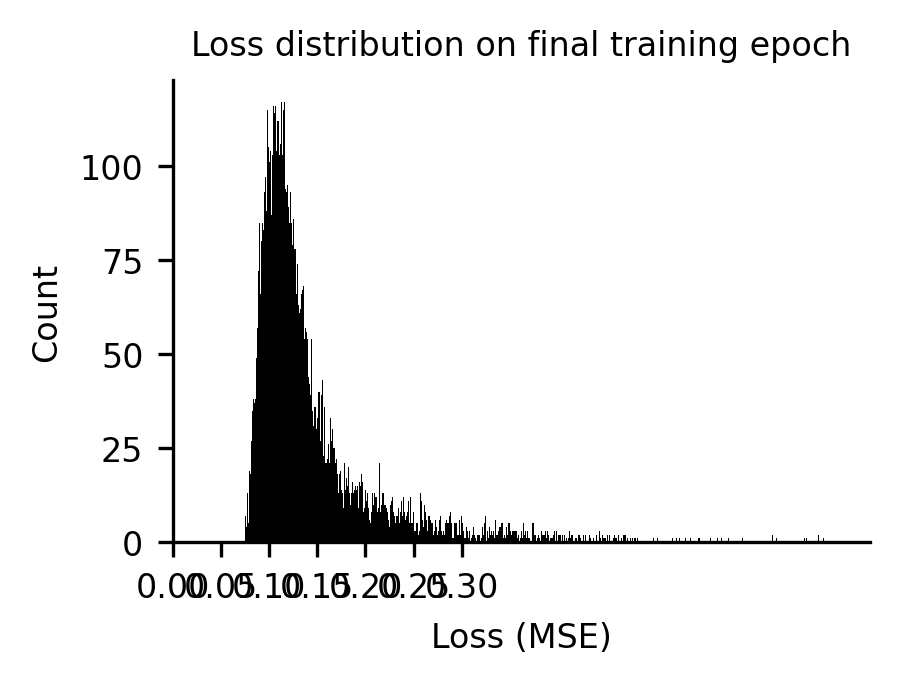

In [247]:
fig, ax = plt.subplots(figsize = (3,2))
ax.hist(result['loss_decay'][-1], bins = 1000, color = 'black')
ax.tick_params(labelsize = fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("Count", fontsize = fontsize)
ax.set_xlabel("Loss (MSE)", fontsize = fontsize)
ax.set_xticks(np.arange(0,0.35,0.05))
#ax.set_ylim(0,60)
ax.set_title("Loss distribution on final training epoch", fontsize = fontsize)

In [115]:
# model = SGCCircuit(bounds=param_bounds, enforce_permutation=P)
# model.load_saved_parameters(perm_results['params'])

In [116]:
# def cumsum(x):
#     total = 0
#     cumsum = []
#     for i in (x):
#         total+=i
#         cumsum.append(total)
#     return np.array(cumsum)

In [117]:
# lsi = np.argsort(perm_results['loss_decay'][-1]) # loss sorting index
# loss_sum = perm_results['loss_decay'][-1].sum()
# plt.plot(cumsum(perm_results['loss_decay'][-1][lsi])/loss_sum)
# plt.ylim(0,1)

In [118]:
from scipy.stats import mode

In [264]:
top_100_1 = []
for i in lsi[:500]:
    top_100_1.append(pd.DataFrame(result['params']['dLGN_params'][i,0,:,:,0,0]).corr(method='spearman').values)
top_100_1 = np.array(top_100_1)
top_100_2 = []
for i in lsi[:500]:
    top_100_2.append(pd.DataFrame(result['params']['dLGN_params'][i,1,:,:,0,0]).corr(method='spearman').values)
top_100_2 = np.array(top_100_2)

bottom_100_1 = []
for i in lsi[-500:]:
    bottom_100_1.append(pd.DataFrame(result['params']['dLGN_params'][i,0,:,:,0,0]).corr(method='spearman').values)
bottom_100_1 = np.array(bottom_100_1)
bottom_100_2 = []
for i in lsi[-500:]:
    bottom_100_2.append(pd.DataFrame(result['params']['dLGN_params'][i,1,:,:,0,0]).corr(method='spearman').values)
bottom_100_2 = np.array(bottom_100_2)

Text(0.525, 0.975, 'Distribution of dLGN parameters post-optimization')

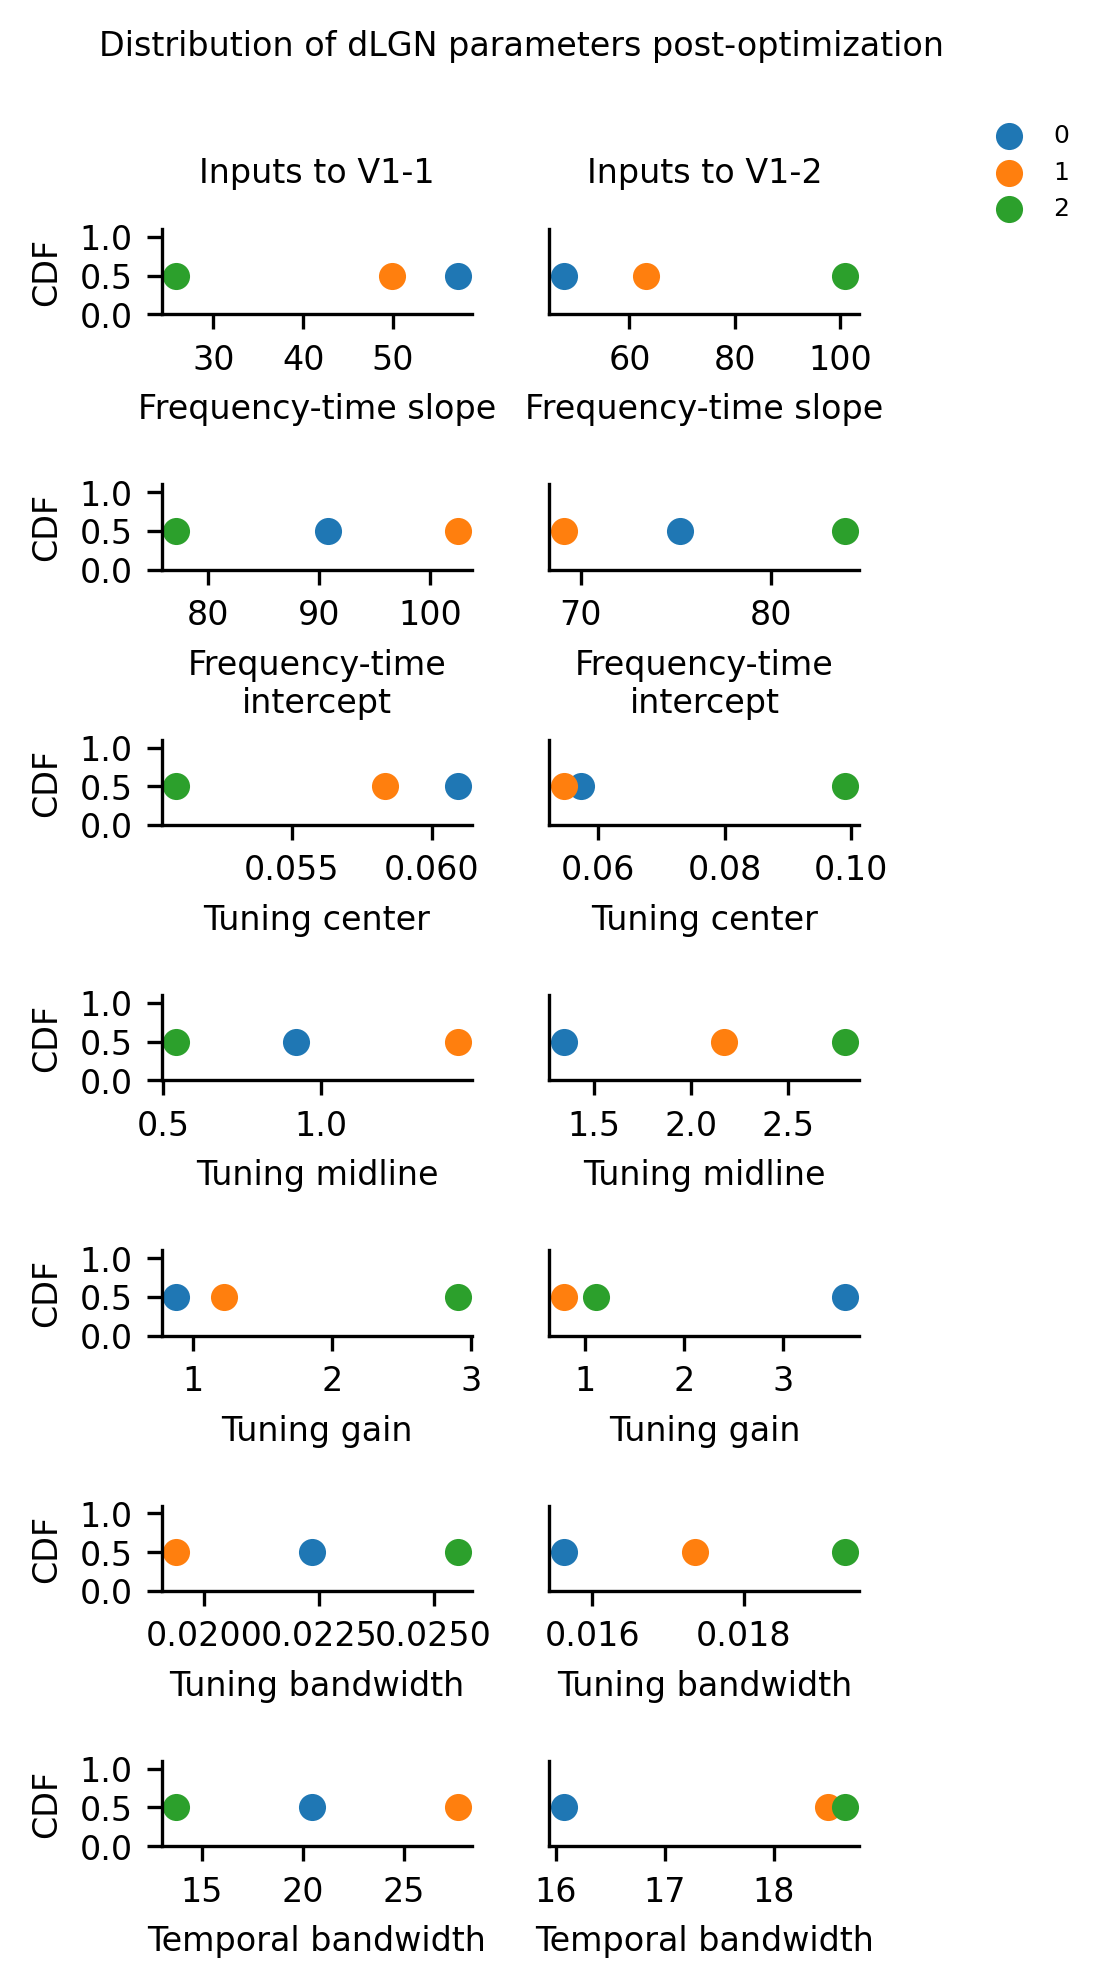

In [138]:
cmap = plt.get_cmap('tab10') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(7,2, figsize = (3,7))

param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            ax[row, u].scatter(model.params['dLGN_params'][lsi[0], u, i, row, 0, 0], [0.5], label = i, linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("CDF", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(0, 1.1)
        ax[row, 1].set_yticks([])
        ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Distribution of dLGN parameters post-optimization", fontsize = fontsize, x = 0.525, y = 0.975)


In [143]:
model2 = SGCCircuit(bounds = param_bounds)
model2.initialize_random_parameters(2,3,100)
optimizer2 = Optimize(model2, epochs=5000, loss_threshold=0)
optimizer2.fit(X, Y_true)

Optimizer initialized with <keras.optimizers.optimizer_v2.adam.Adam object at 0x000002744674AE80>
Training step = 0, N_exploration_samples = 100,
min_loss = 1.8044122457504272
med_loss = 14.162368774414062
max_loss = 60.65174865722656

Training step = 100, N_exploration_samples = 100,
min_loss = 1.1245571374893188
med_loss = 11.169628143310547
max_loss = 49.51068878173828

Training step = 200, N_exploration_samples = 100,
min_loss = 0.7194547653198242
med_loss = 8.317729949951172
max_loss = 40.17063903808594

Training step = 300, N_exploration_samples = 100,
min_loss = 0.48897525668144226
med_loss = 6.141271591186523
max_loss = 32.463523864746094

Training step = 400, N_exploration_samples = 100,
min_loss = 0.36594700813293457
med_loss = 4.692047119140625
max_loss = 26.13184928894043

Training step = 500, N_exploration_samples = 100,
min_loss = 0.29570069909095764
med_loss = 3.627701759338379
max_loss = 20.948650360107422

Training step = 600, N_exploration_samples = 100,
min_loss = 0.

<tf.Tensor: shape=(5000, 100), dtype=float16, numpy=
array([[ 5.5    , 12.44   ,  6.72   , ..., 43.28   , 15.22   , 13.555  ],
       [ 5.48   , 12.39   ,  6.707  , ..., 43.2    , 15.18   , 13.516  ],
       [ 5.465  , 12.34   ,  6.695  , ..., 43.1    , 15.14   , 13.48   ],
       ...,
       [ 0.0785 ,  0.08655,  0.0885 , ...,  0.1265 ,  0.1721 ,  0.1138 ],
       [ 0.0785 ,  0.08655,  0.0885 , ...,  0.1263 ,  0.1721 ,  0.1138 ],
       [ 0.0785 ,  0.08655,  0.08844, ...,  0.1263 ,  0.1721 ,  0.1138 ]],
      dtype=float16)>

In [139]:
R = model.predict(X)

In [144]:
model2.soft_perm

<tf.Variable 'permutation_matrix:0' shape=(100, 7, 2, 3, 3) dtype=float32, numpy=
array([[[[[-2.6379716 ,  2.3847325 , -0.07056232],
          [ 0.5289898 , -1.2339472 ,  0.5532133 ],
          [ 1.7537618 , -1.3747871 ,  1.4249082 ]],

         [[ 0.842764  , -1.8128272 ,  1.2642273 ],
          [ 1.6666894 , -0.81974727,  1.3654032 ],
          [-1.1601088 ,  2.274626  , -1.6095843 ]]],


        [[[-1.4030038 ,  0.97945976, -0.4210707 ],
          [ 0.45634454, -0.64586985, -0.4125833 ],
          [-1.8762585 , -1.7432588 ,  1.5977447 ]],

         [[ 0.01711447, -1.033322  , -0.15524924],
          [ 0.04634185,  0.48997813, -0.86833656],
          [-0.37910885,  1.9160255 , -1.5460017 ]]],


        [[[-1.3979768 ,  1.0774496 , -1.0921396 ],
          [-0.20238069, -0.59208226,  3.8553162 ],
          [ 1.192461  , -1.1984097 , -0.29321504]],

         [[-0.8162105 , -2.1004472 ,  2.9922097 ],
          [ 1.8847837 ,  0.340286  , -0.15549631],
          [-2.847238  ,  2.2247276 , 

In [145]:
model2.sinkhorn(model2.soft_perm)

<tf.Tensor: shape=(100, 7, 2, 3, 3), dtype=float32, numpy=
array([[[[[0.00627791, 0.9050444 , 0.08780109],
          [0.44218627, 0.07202669, 0.48618147],
          [0.5515358 , 0.02292897, 0.42601746]],

         [[0.39896283, 0.02325136, 0.5796524 ],
          [0.56459624, 0.0389688 , 0.398187  ],
          [0.03644096, 0.9377799 , 0.02216058]]],


        [[[0.12708779, 0.78726137, 0.08630486],
          [0.771621  , 0.14656924, 0.08232221],
          [0.10129134, 0.06616949, 0.831373  ]],

         [[0.3756947 , 0.04866555, 0.57566214],
          [0.43356395, 0.25021148, 0.31622955],
          [0.19074136, 0.70112294, 0.10810825]]],


        [[[0.08061972, 0.8938844 , 0.03390312],
          [0.05052743, 0.03191965, 0.9051853 ],
          [0.868853  , 0.07419597, 0.06091164]],

         [[0.05838898, 0.00422363, 0.94024837],
          [0.91894376, 0.05124061, 0.04267191],
          [0.0226673 , 0.9445358 , 0.01707976]]],


        ...,


        [[[0.05422534, 0.03289807, 0.901406 

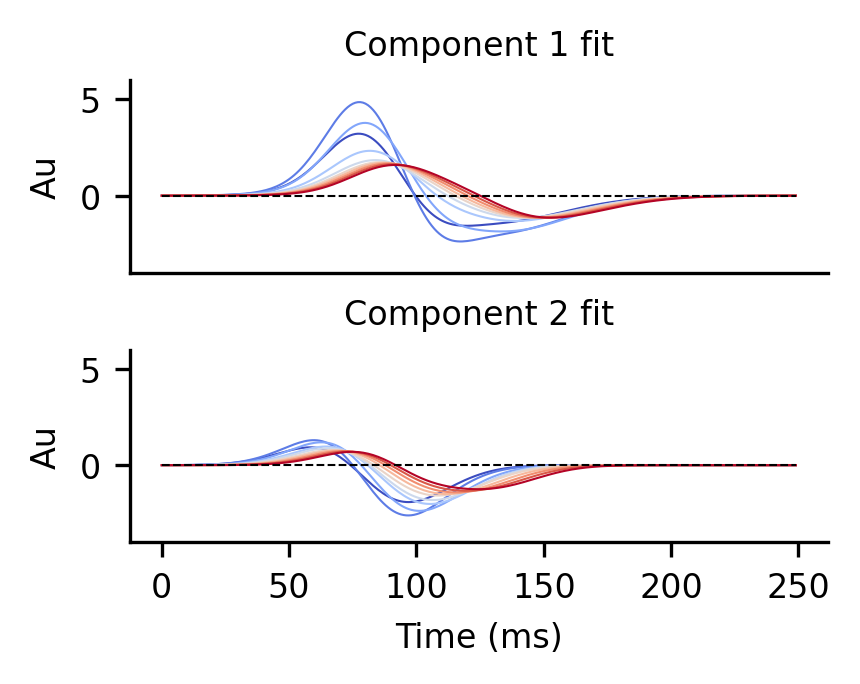

In [140]:
from matplotlib import rcParams, cycler
cmap = plt.get_cmap('coolwarm') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(2, figsize = (3,2))

ax[0].plot(R[lsi[0]][0].numpy().T, linewidth = linewidth)
ax[0].set_title("Component 1 fit", fontsize = fontsize)
ax[0].set_xticks([])

ax[1].plot(R[lsi[0]][1].numpy().T, linewidth = linewidth)
ax[1].set_title('Component 2 fit', fontsize = fontsize)
for i in range(2):
    ax[i].set_ylabel("Au", fontsize = fontsize)
    ax[i].plot(np.zeros(250), '--', color = 'black', linewidth = linewidth)
    ax[i].tick_params(labelsize = fontsize)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    
ax[0].set_ylim(-4,6)
ax[1].set_ylim(-4,6)
ax[1].set_xlabel("Time (ms)", fontsize = fontsize)
fig.subplots_adjust(hspace=0.4)

<Axes: >

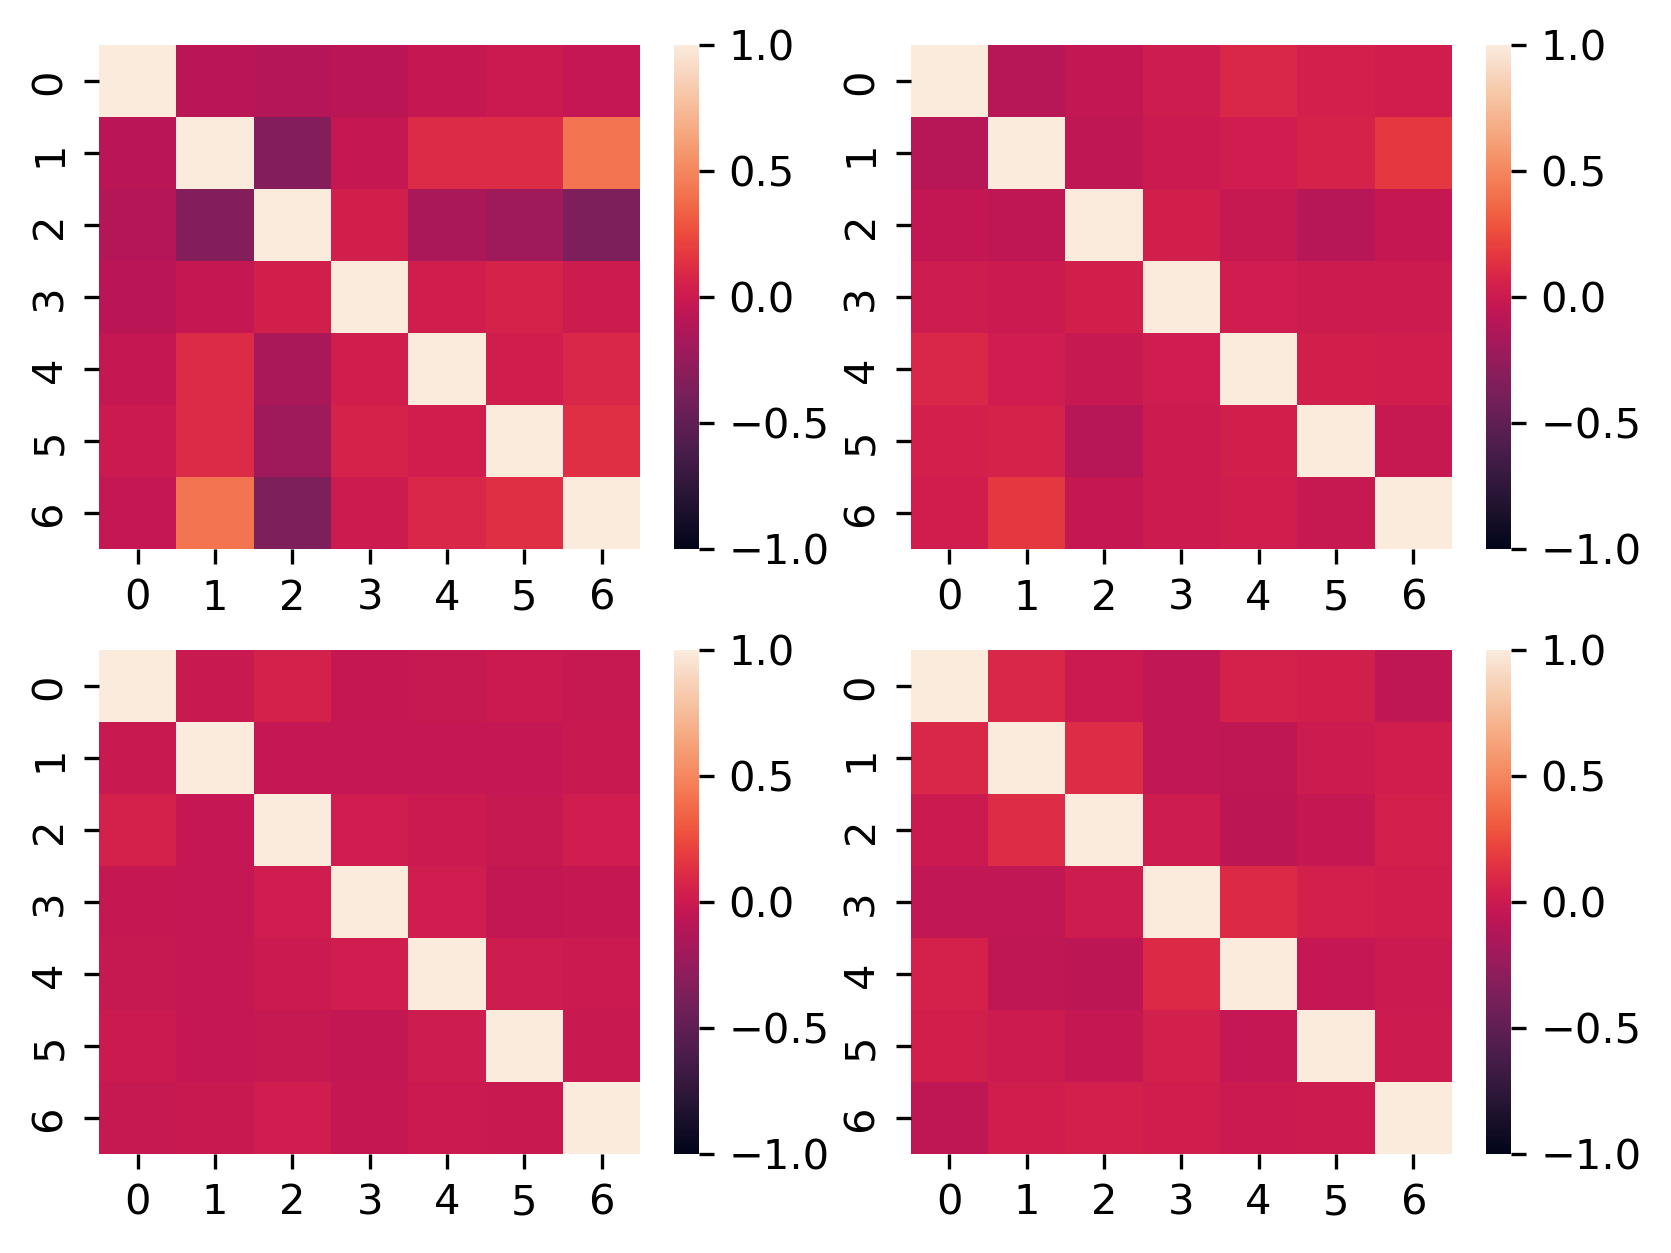

In [265]:
fig, ax = plt.subplots(2,2)

sns.heatmap(np.mean(top_100_1, 0), ax = ax[0,0], vmin = -1, vmax = 1)
sns.heatmap(np.mean(top_100_2, 0), ax = ax[0,1], vmin = -1, vmax = 1)

sns.heatmap(np.mean(bottom_100_1, 0), ax = ax[1,0], vmin = -1, vmax = 1)
sns.heatmap(np.mean(bottom_100_2, 0), ax = ax[1,1], vmin = -1, vmax = 1)

In [32]:
model.sinkhorn(model.soft_perm)

<tf.Tensor: shape=(4000, 7, 2, 3, 3), dtype=float32, numpy=
array([[[[[0.02885458, 0.9419811 , 0.02139255],
          [0.16395952, 0.01822668, 0.82216793],
          [0.80718595, 0.03979225, 0.15643951]],

         [[0.15793481, 0.78033435, 0.06210362],
          [0.6311056 , 0.16274843, 0.20608312],
          [0.21095958, 0.05691717, 0.7318132 ]]],


        [[[0.0435836 , 0.9085216 , 0.02123498],
          [0.8451131 , 0.08449655, 0.07407366],
          [0.11130325, 0.00698188, 0.9046914 ]],

         [[0.09014969, 0.8253869 , 0.08577086],
          [0.87064034, 0.07843898, 0.04840073],
          [0.03920997, 0.09617422, 0.86582845]]],


        [[[0.29815397, 0.4329892 , 0.26885682],
          [0.35519543, 0.3270807 , 0.31772384],
          [0.34665057, 0.23993005, 0.41341937]],

         [[0.9266603 , 0.01874968, 0.05048981],
          [0.02916104, 0.92532283, 0.04058427],
          [0.04417861, 0.05592753, 0.90892595]]],


        ...,


        [[[0.01956669, 0.20100415, 0.780510

In [34]:
p_choices = np.array(list(permutations(permutations(np.arange(3)),2)))

In [81]:
w_indxr = np.zeros((1,30))
w_indxr[:,15] = 1

In [82]:
p_choices.shape

(30, 2, 3)

In [ ]:
p_choices.shape

(30, 2, 3)

In [83]:
P.shape

TensorShape([6435, 7, 2, 3, 3])

In [77]:

w_indxr.shape

(3, 30, 2)

In [64]:
(p_choices @ w_indxr).shape

(30, 2, 2)

In [17]:
all_perm = []
for i in range(4000):
    all_perm.append(pd.DataFrame(model.dlgn_scaled[i,0,:,:,0,0].numpy()).corr(method='spearman').values)
all_perm = np.array(all_perm)

<Axes: >

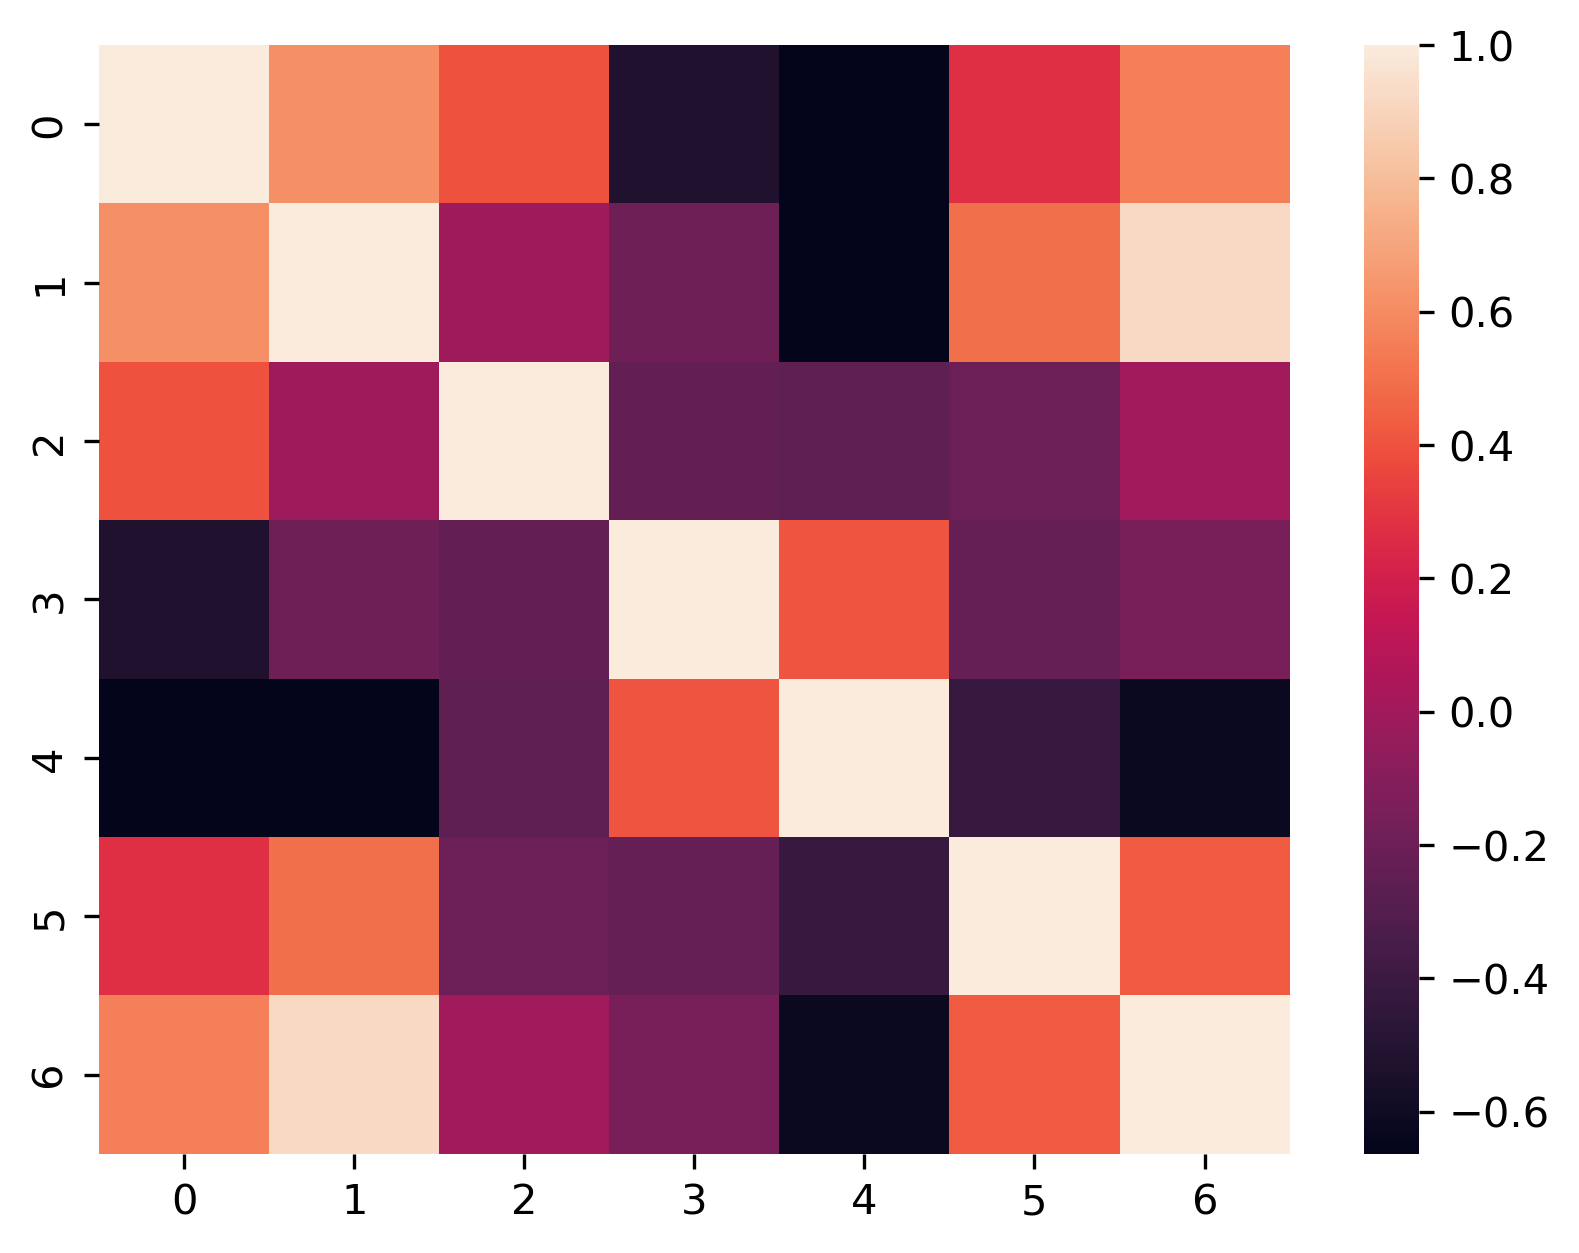

In [96]:
sns.heatmap(np.mean(all_perm, axis=0))

In [19]:
# fig, ax = plt.subplots(2,2, )
# sns.heatmap(np.median(top_100_1, 0), ax = ax[0,0], vmin = -1, vmax = 1)
# sns.heatmap(top_100_2.mean(0), ax = ax[0,1], vmin = -1, vmax = 1)

# sns.heatmap(np.median(bottom_100_1, 0), ax = ax[1,0], vmin = -1, vmax = 1)
# sns.heatmap(bottom_100_2.mean(0), ax = ax[1,1], vmin = -1, vmax = 1)

In [20]:
import pandas as pd

## 1: Fully order correlated (1,2,3) => (1,2,3)
## 0.5: Partially order correlated (1,2,3) => (1,3,2), (2,1,3)
## -1: Fully order anticorrelated (1,2,3) => (3,2,1)
## -0.5: Partially order anticorrelated (1,2,3) => (2,3,1), (3,1,2)
df = pd.DataFrame({'a': [1,2,3], 'b': [3,1,2]})
correlation = df.corr(method='spearman')
correlation


,a,b
a,1.0,-0.5
b,-0.5,1.0
